In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [2]:
x=df[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']]
y=df['Outcome']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [4]:
from sklearn.tree import DecisionTreeClassifier,plot_tree


In [5]:
nn=DecisionTreeClassifier(criterion='entropy',max_depth=75,random_state=42)
model=nn.fit(x_train,y_train)
model

,criterion,'entropy'
,splitter,'best'
,max_depth,75
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [6]:
y_pred=model.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
cm

array([[76, 23],
       [20, 35]])

In [7]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
ACCURACY=(TN+TP)/(TP+TN+FP+FN)
ERRORRATE=FP+FN/TP+TN+FP+FN
SENSITIVITY=TP/TP+FN
SPACIFICITY=TN/TN+FP
print("Accuracy:",ACCURACY)
print("ERRORRATE",ERRORRATE)
print("SENSITIVITY",SENSITIVITY)
print("SPACIFICITY",SPACIFICITY)

Accuracy: 0.7207792207792207
ERRORRATE 142.57142857142856
SENSITIVITY 21.0
SPACIFICITY 24.0


In [8]:
from sklearn.metrics import accuracy_score,recall_score

In [9]:
acuracyscore=accuracy_score(y_test,y_pred)
acuracyscore

0.7207792207792207

In [10]:
error_rate=1-acuracyscore
error_rate

0.27922077922077926

In [11]:
sensitivity=recall_score(y_test,y_pred)
sensitivity

0.6363636363636364

In [12]:
precision=TP/(TP+FP)
precision

np.float64(0.603448275862069)

In [13]:
import matplotlib.pyplot as plt

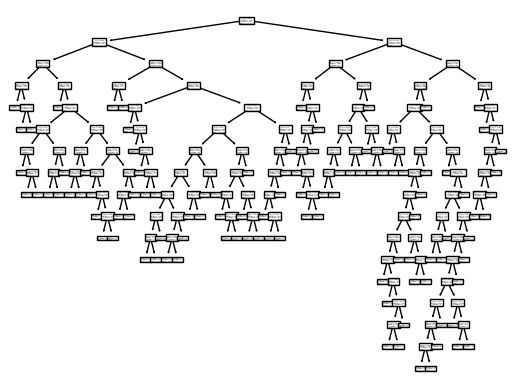

In [14]:
plot_tree(nn)
plt.show()